Creates the final signal catalog from the signal list, satellite list and satbeam file. 

## 1. Initialization

Imports and necessary parameters.

In [1]:
## ----- IPYTHON COMMANDS ----- ##
%load_ext autoreload
%autoreload 2


In [2]:
## ----- IMPORTS ----- ##
import sys
sys.path.insert(0, "./initialization/")
from imports import *
import parameters_1554156377 as pm
import time
import satellite_RFI.src.tle_mapping as tle


In [20]:
## ----- PARAMETERS ----- ##
path_beam = "{}satbeams_{}_{}_{}-{}.pkl".format(pm.folder, pm.block, pm.beam_model, *pm.freq_range)
path_knumbers = "knumbers_1551055211.csv"
path_catalog = pm.folder + f"catalog_{pm.block}.csv"


## 2. Creating the new beams file

The satbeam file is now corrected and doesn't need to be formatted differently, so we are just checking if the plots are close enough between the old and new versions.

In [8]:
# getting it
start = time.perf_counter()
data = pickle.load(open(path_beam,"rb",), encoding="latin1")
elapsed = time.perf_counter() - start
print(f"This took {elapsed:.2f} seconds, or {elapsed/60:.2f} minutes".format())

# getting satellite information
satellites = pd.read_csv(pm.folder + "satellites.csv")
satellites.set_index("NORAD ID",inplace=True)


This took 1.84 seconds, or 0.03 minutes


In [9]:
# cutting in the frequency range
idx_start = np.where(pm.frequency > pm.freq_range[0])[0][0] - 1
idx_end = np.where(pm.frequency > pm.freq_range[1])[0][0] + 1
fs = pm.frequency[idx_start:idx_end]
ts = pm.nd_s0

# showing axis
print("Frequency length:",len(fs))
print("Time length:",len(ts))
print(np.shape(data[list(data.keys())[0]]))


Frequency length: 2394
Time length: 2189
(2393, 2189)


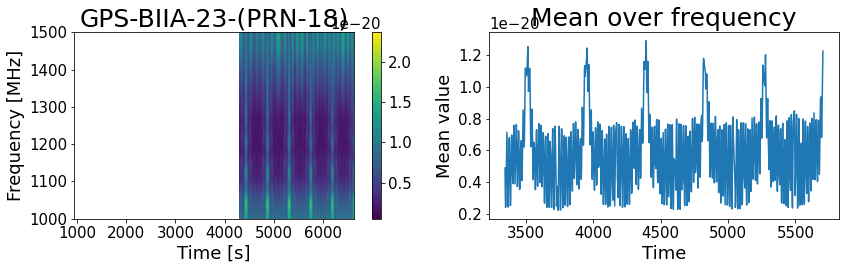

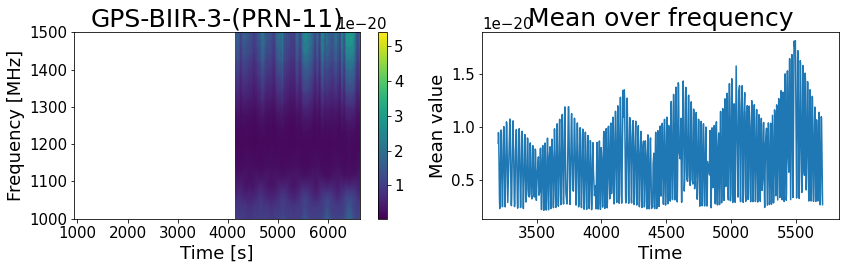

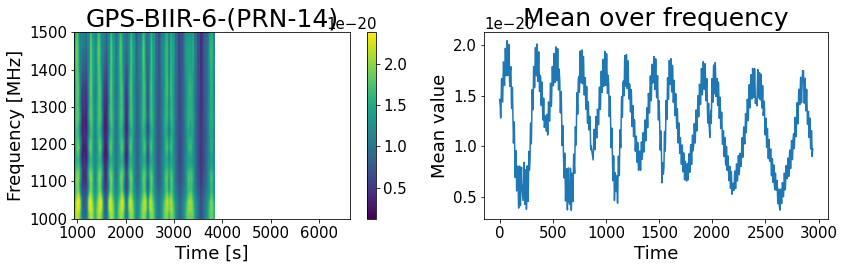

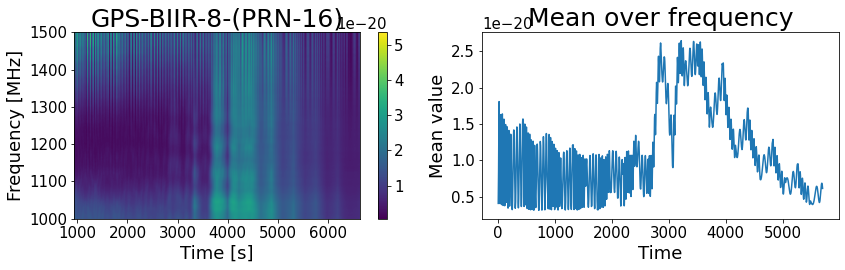

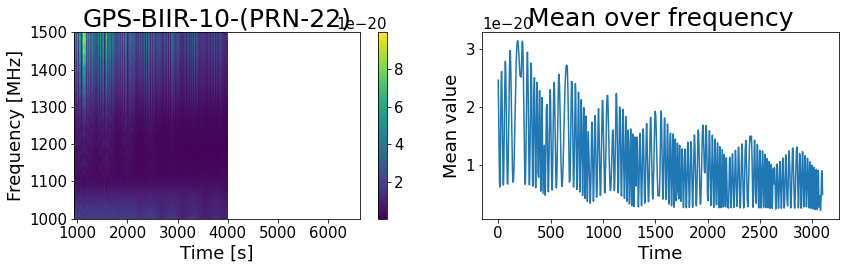

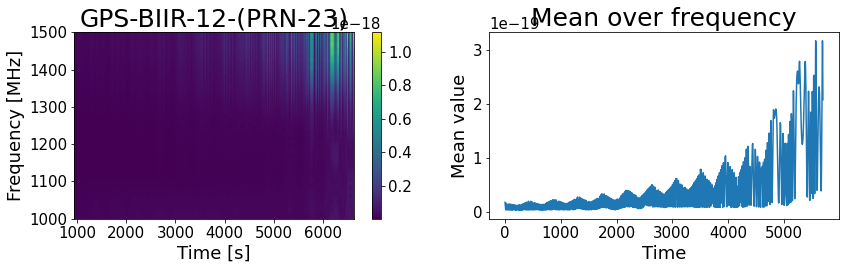

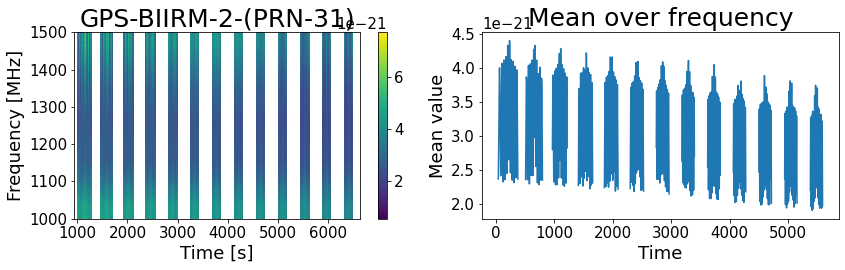

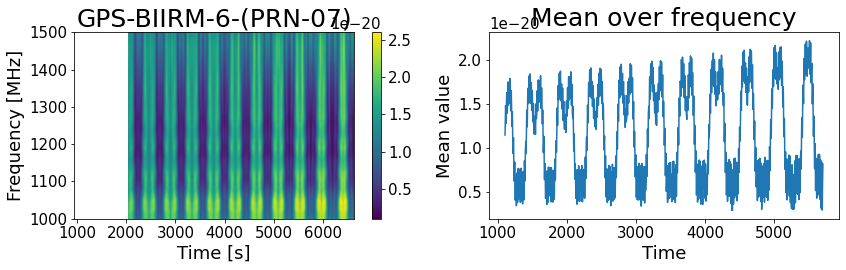

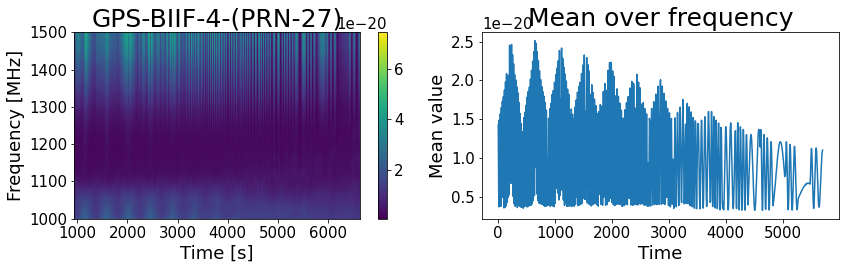

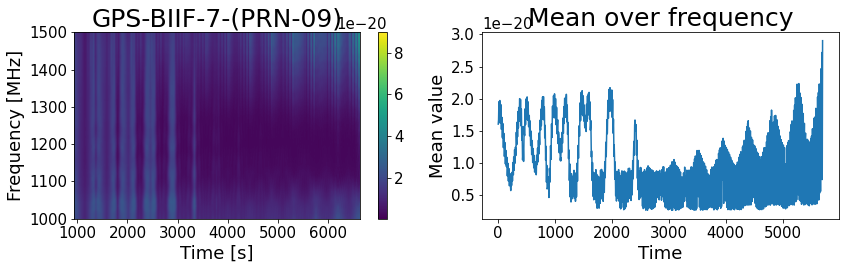

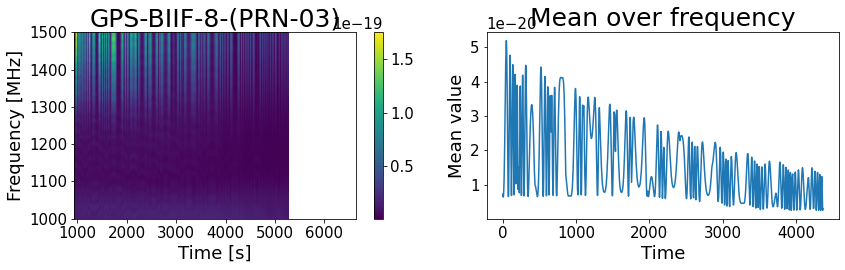

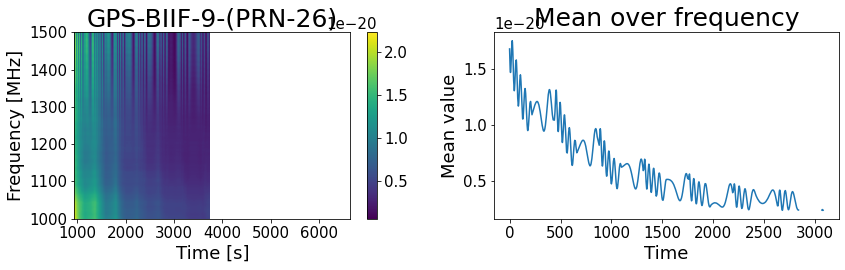

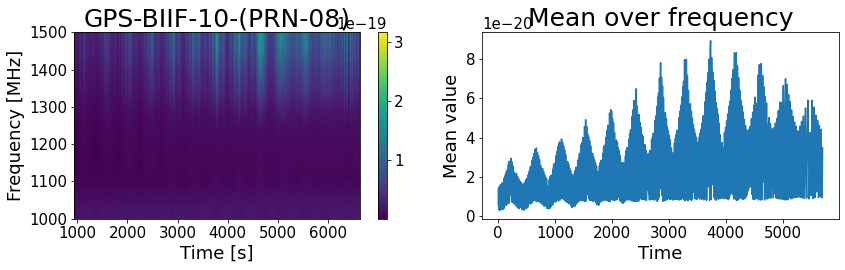

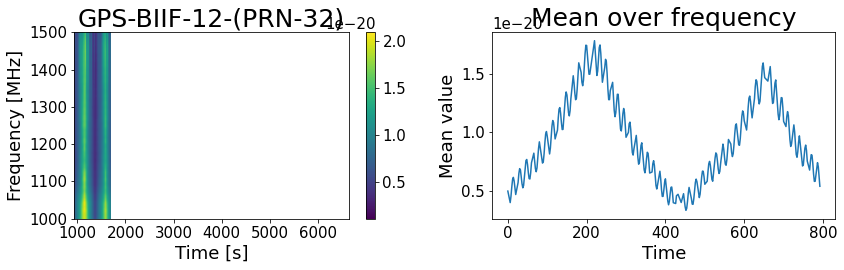

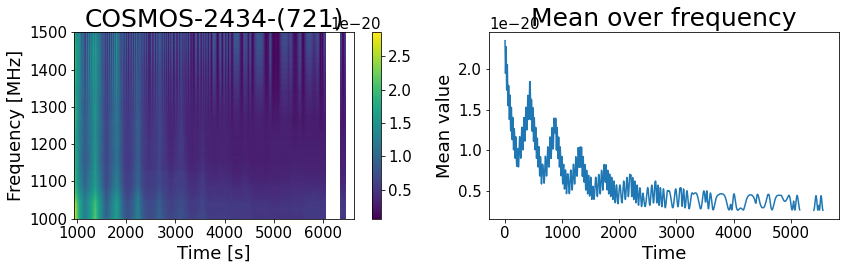

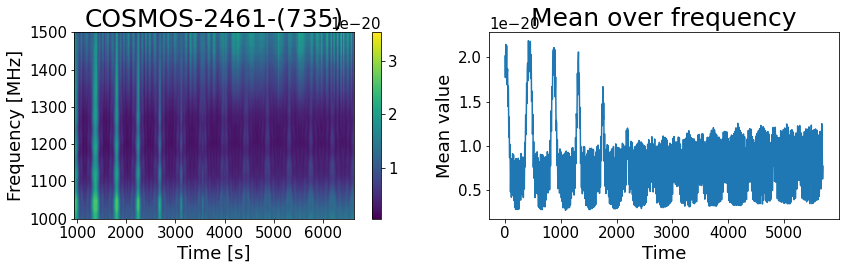

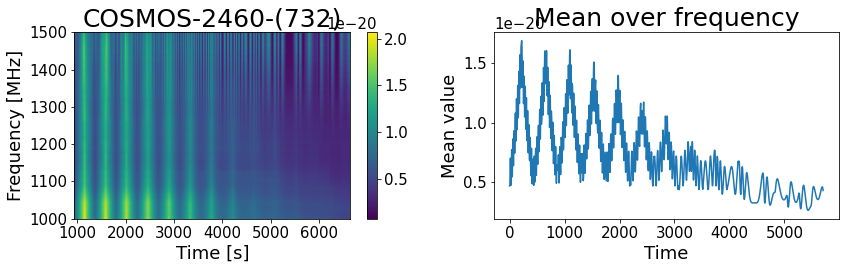

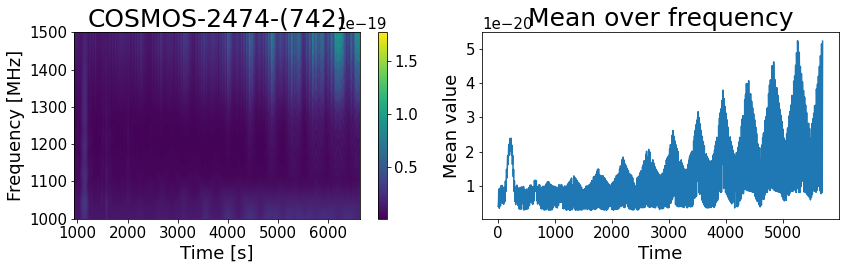

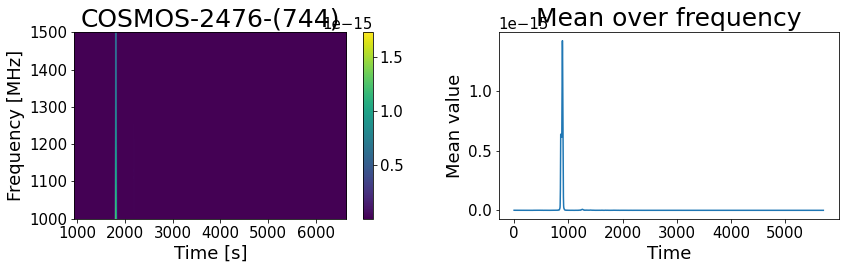

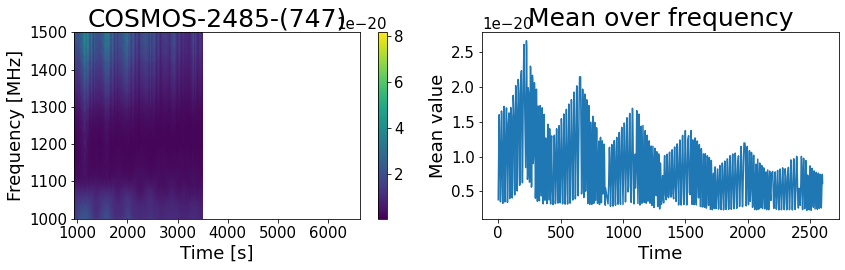

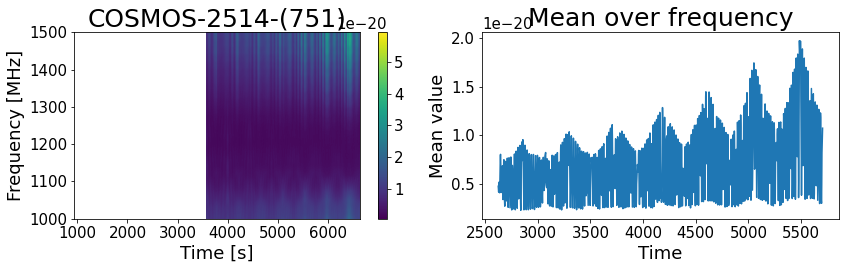

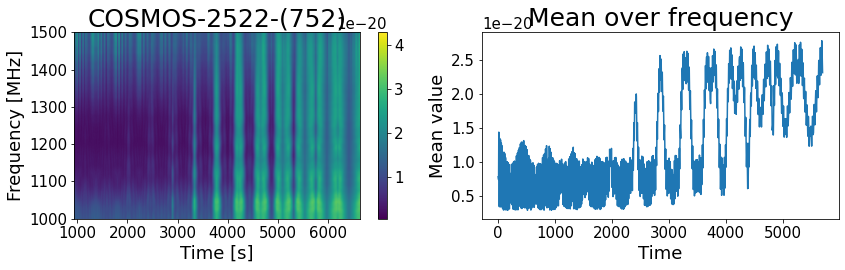

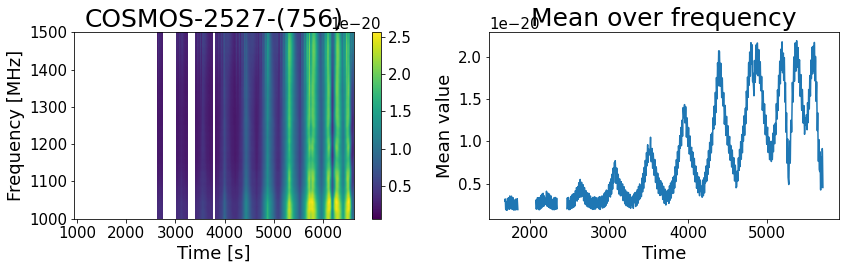

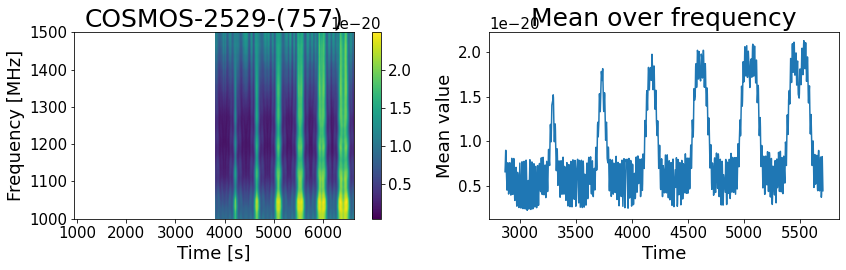

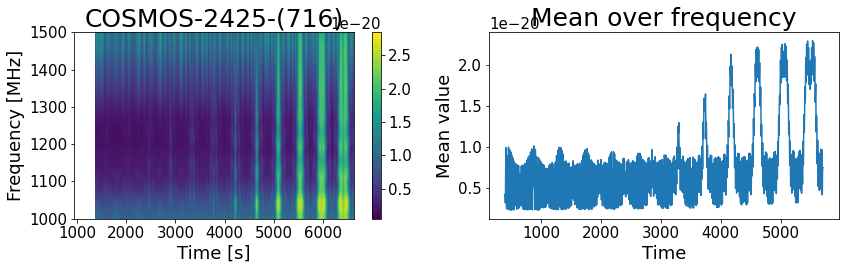

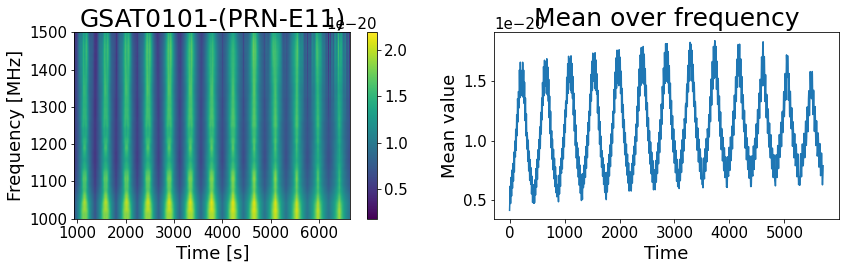

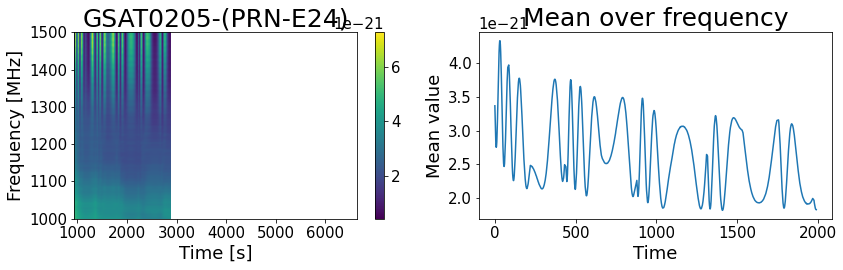

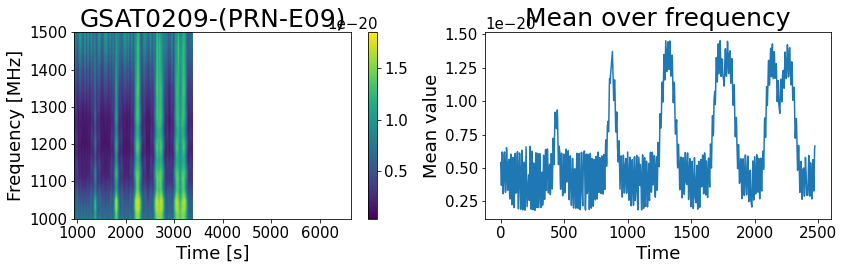

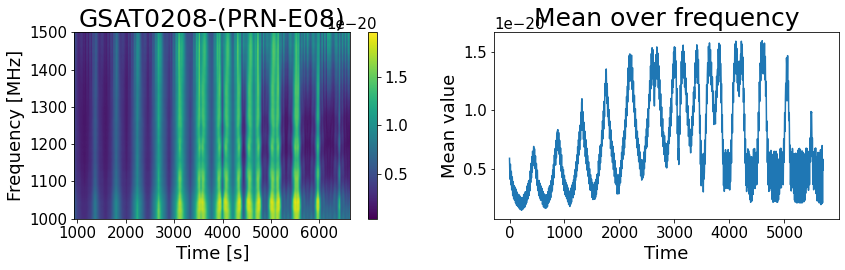

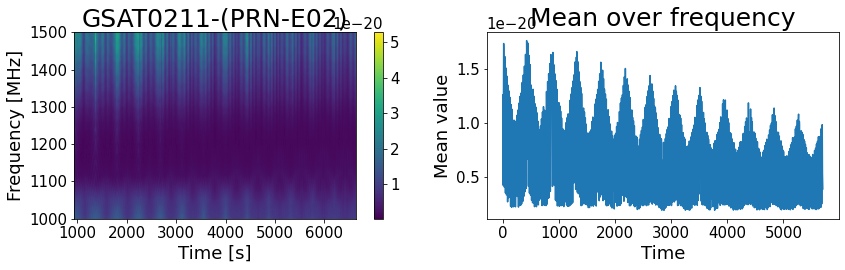

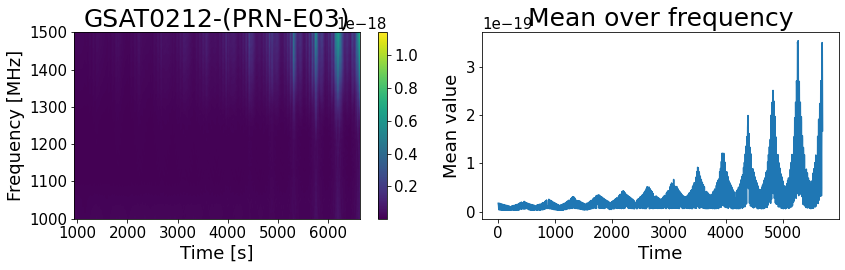

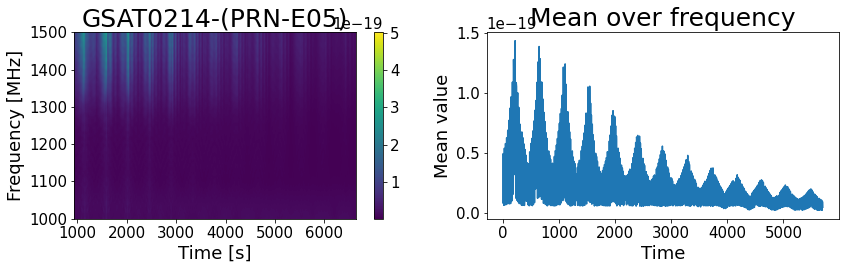

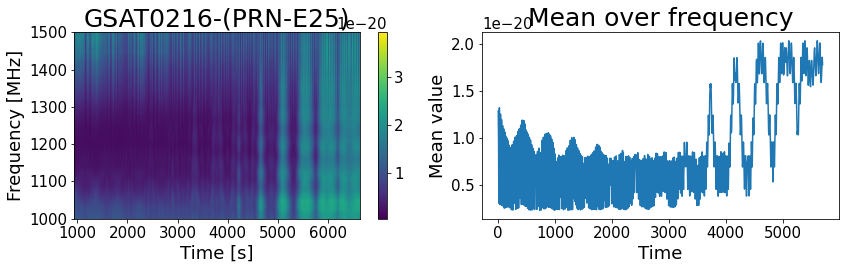

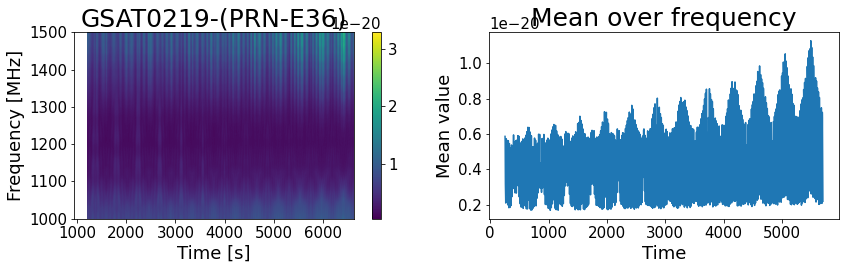

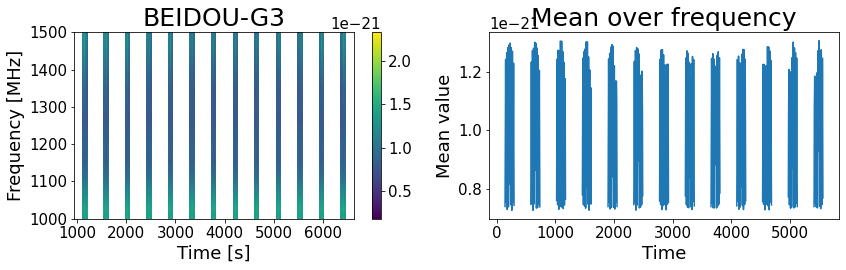

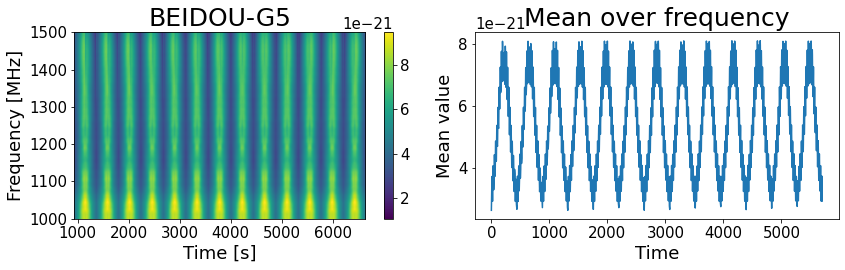

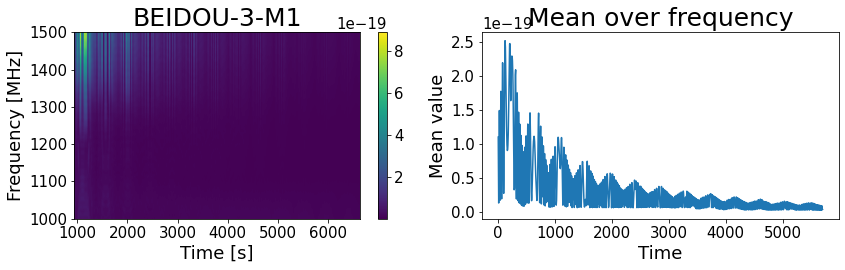

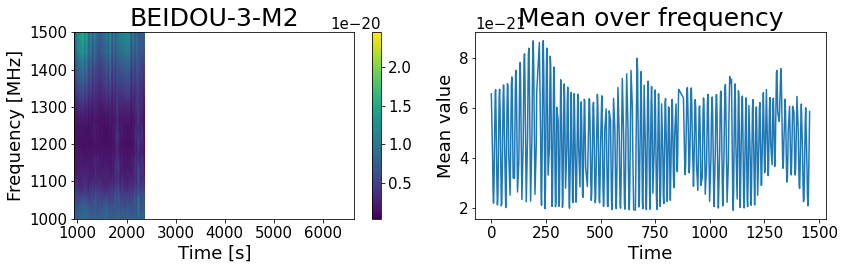

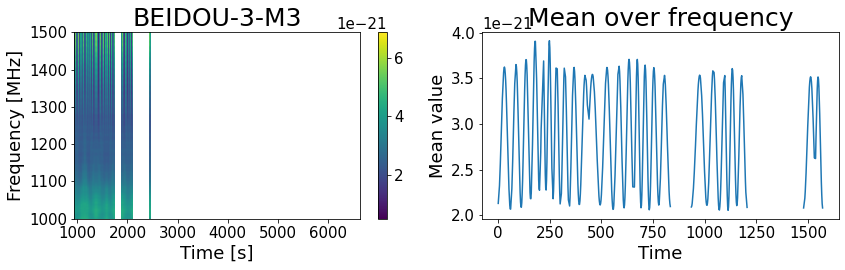

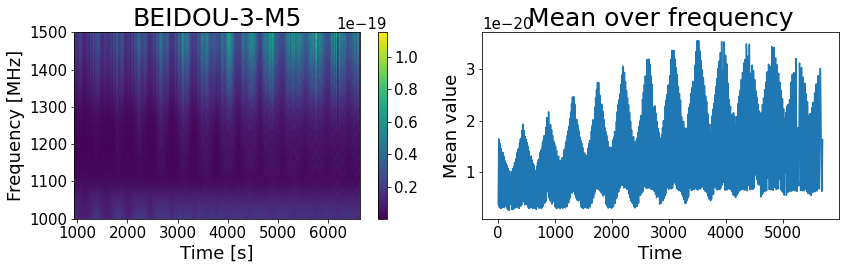

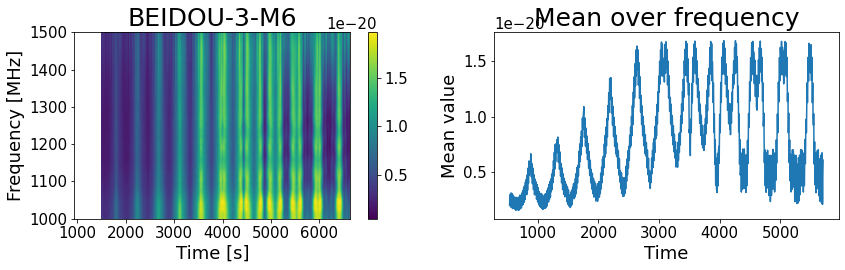

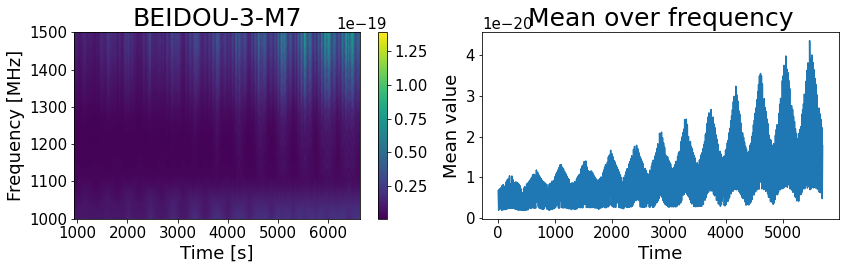

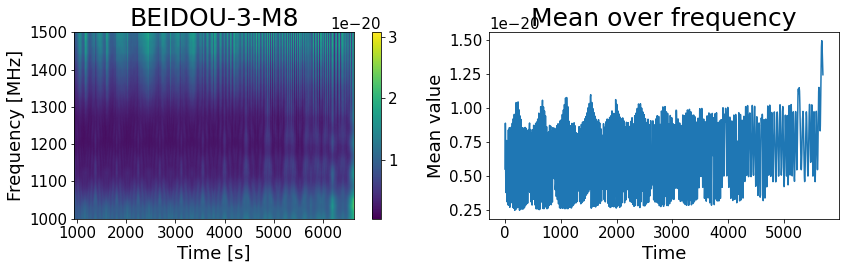

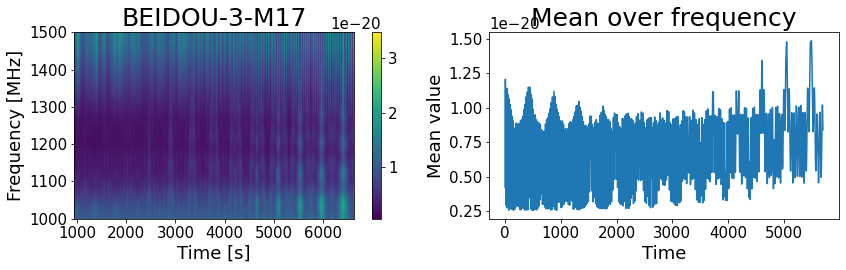

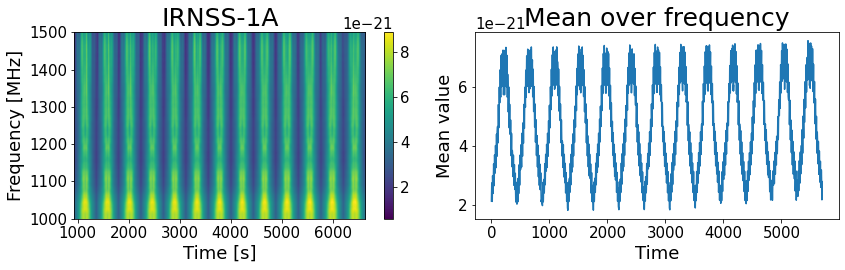

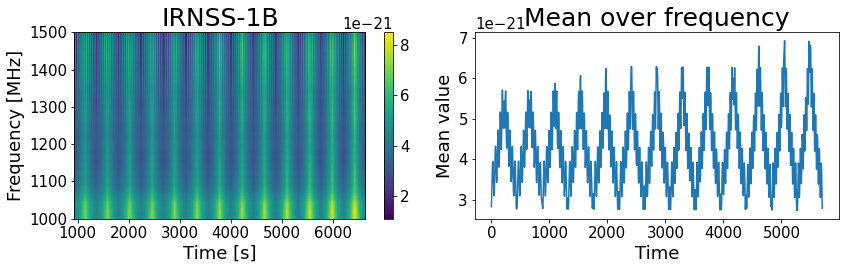

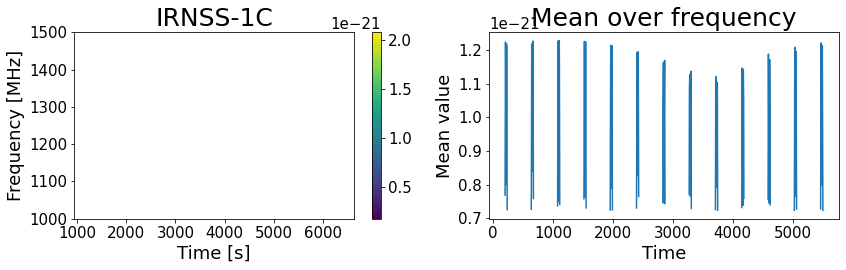

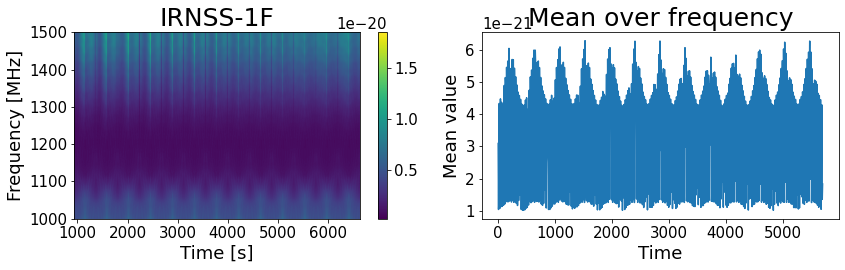

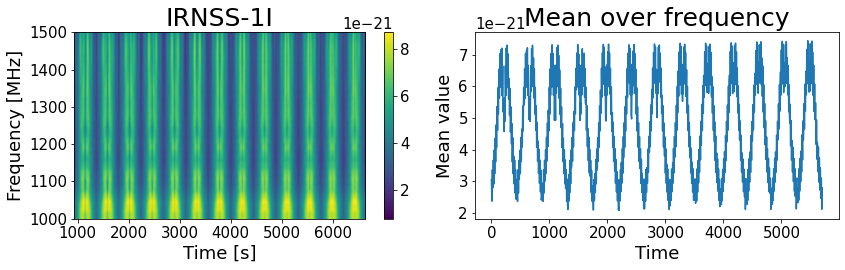

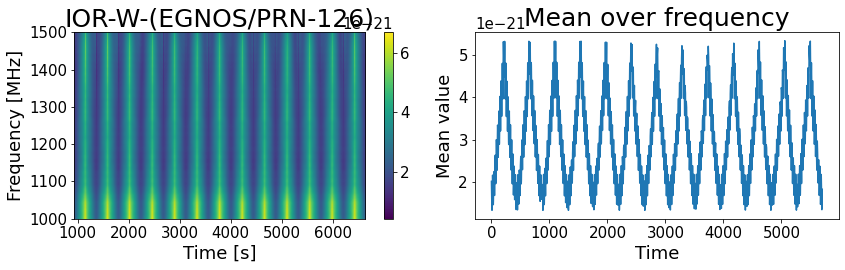

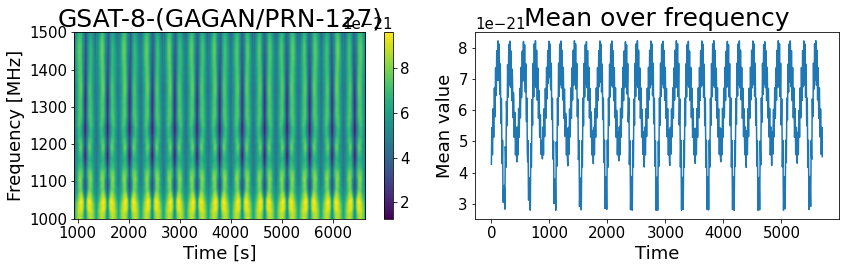

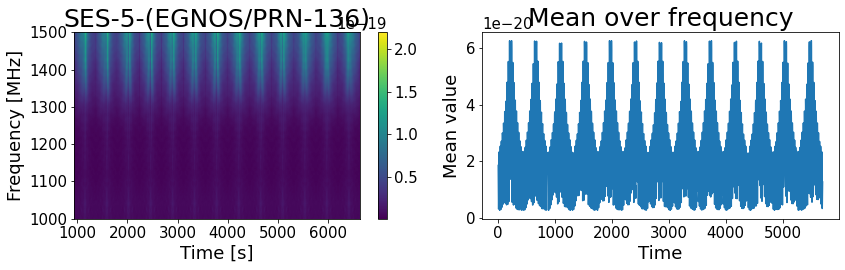

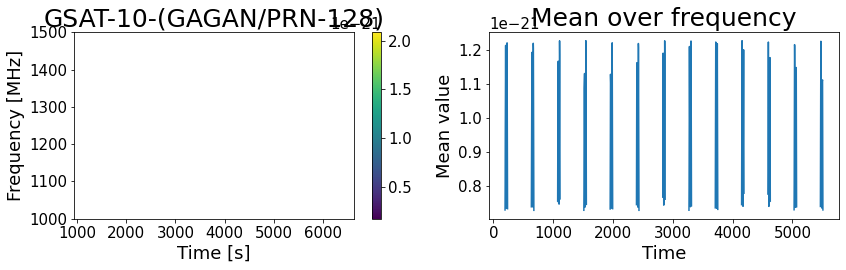

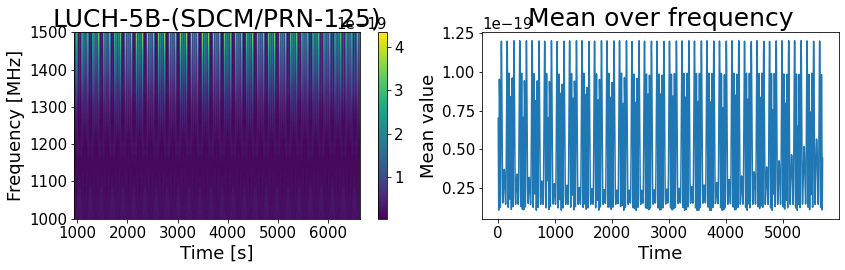

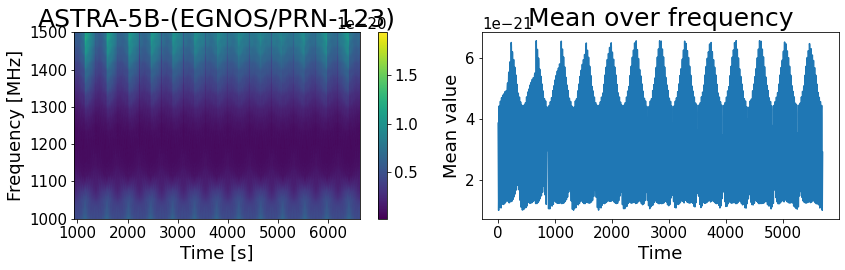

In [10]:
# plotting satbeam maps
for i in data.keys():
    # Left: complete map
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    dplot = np.ma.masked_equal(data[i], 0)
    im = ax1.imshow(dplot, extent=[ts[0],ts[-1],fs[0],fs[-1]], 
                    origin="lower",aspect="auto")
    ax1.set_title(satellites.loc[i,f"Name {pm.block}"])
    ax1.set_xlabel("Time [s]")
    ax1.set_ylabel("Frequency [MHz]")
    fig.colorbar(im, ax=ax1)
        
    # Right: mean over frequency
    ax2.plot(ts-ts[0], np.ma.mean(dplot, axis=0))
    ax2.set_title("Mean over frequency")
    ax2.set_xlabel("Time")
    ax2.set_ylabel("Mean value")
    plt.tight_layout()
    plt.show()
    print()
    

## 3. Creating the final signal list (specific to the particular observation)

#### A. Getting data

And now we create a signal catalog of all signals to fit in the data, where we use only the satellites that appear in the angular position maps. 

In [11]:
# getting signal and satellite list
signals = pd.read_csv(pm.folder + "signals.csv")
satellites = pd.read_csv(pm.folder + "satellites.csv")
satellites.set_index("NORAD ID", inplace=True)


#### B. Creating new updated dataframe based on generation

We now create a signal list same as before, but now taking into account the specific generation that the satellite belongs to.

In [12]:
# creating necessary lists
data2 = []
IDrow = []

print("Selecting signals...")
for ID in data.keys():

    # selecting the generation and constellation
    gen = satellites.at[ID,"Generation"]
    cons = satellites.at[ID,"Constellation"]

    # parsing through the signals
    signals2 = signals[signals["Constellation"]==cons]
    for i in signals2.index:
        if gen in signals2.loc[i,"Generations"].split(","):
            data2.append(signals2.loc[i])
            IDrow.append(ID)
print("Done!")

# creating dataframe
data2 = pd.DataFrame(data2)
data2.insert(0, "NORAD ID", IDrow)


Selecting signals...
Done!


#### C. Dealing with GLONASS k numbers

The k numbers make it so that the central frequencies in L1:L1OF(C/A), L1:L1SF(P), L2:L2OF(C/A) and L2:L2SF(P) are now $f_{L1}=1602.0+0.5625~k\text{ MHz}$ and $f_{L2}=1246.0+0.4375~k\text{ MHz}$. The satellite COSMOS-2425 doesn't show any k in the original russian list of september (even though it technically transmitted until 2021). For that reason, even though it is present in the satbeam maps, we will remove it from the observations. 


In [14]:
# getting k numbers
ks = pd.read_csv(pm.folder + path_knumbers)
ks = ks.set_index("NORAD ID")


In [15]:
# parsing through GLONASS satellites
print("Substituting correct frequencies...")
for ID in data.keys():
    if satellites.at[ID,"Constellation"]=="GLONASS":
        # getting quantities
        k = ks.at[ID,"k"]
        mask1 = data2["NORAD ID"]==ID
        
        # substituting values
        data2.loc[mask1 & (data2["Signal"]=="L1:L1OF(C/A)"), "Frequency(MHz)"] = 1602.0 + k*0.5625
        data2.loc[mask1 & (data2["Signal"]=="L1:L1SF(P)"), "Frequency(MHz)"] = 1602.0 + k*0.5625
        data2.loc[mask1 & (data2["Signal"]=="L2:L2OF(C/A)"), "Frequency(MHz)"] = 1246.0 + k*0.4375
        data2.loc[mask1 & (data2["Signal"]=="L2:L2SF(P)"), "Frequency(MHz)"] = 1246.0 + k*0.4375
print("Done!")


Substituting correct frequencies...
Done!


In [17]:
# remove satellite without k number
data2 = data2[data2["NORAD ID"]!=29670]


In [18]:
display(data2[data2["Constellation"]=="GLONASS"])

,NORAD ID,Constellation,Generations,Signal,Frequency(MHz),Rate(MHz),Modulation,P(dBW),G(dBi)
8,32393,GLONASS,"M,M+,K1,K2",L1:L1OF(C/A),1600.8750,0.5115,BPSK(0.5),10.0,10.0
9,32393,GLONASS,"M,M+,K1,K2",L1:L1SF(P),1600.8750,5.1150,BPSK(5),10.0,10.0
10,32393,GLONASS,"M,M+,K1,K2",L2:L2OF(C/A),1245.1250,0.5115,BPSK(0.5),10.0,10.0
11,32393,GLONASS,"M,M+,K1,K2",L2:L2SF(P),1245.1250,5.1150,BPSK(5),10.0,10.0
8,36401,GLONASS,"M,M+,K1,K2",L1:L1OF(C/A),1603.1250,0.5115,BPSK(0.5),10.0,10.0
9,36401,GLONASS,"M,M+,K1,K2",L1:L1SF(P),1603.1250,5.1150,BPSK(5),10.0,10.0
10,36401,GLONASS,"M,M+,K1,K2",L2:L2OF(C/A),1246.8750,0.5115,BPSK(0.5),10.0,10.0
11,36401,GLONASS,"M,M+,K1,K2",L2:L2SF(P),1246.8750,5.1150,BPSK(5),10.0,10.0
8,36402,GLONASS,"M,M+,K1,K2",L1:L1OF(C/A),1603.6875,0.5115,BPSK(0.5),10.0,10.0
9,36402,GLONASS,"M,M+,K1,K2",L1:L1SF(P),1603.6875,5.1150,BPSK(5),10.0,10.0


#### D. Rewriting data

Name will depend on the observation because this is tailored specifically to the observation that we are fitting (only satellites in here are the ones appearing in the beam maps); in order to fit other data, this process needs to be repeated (but the signal and satellite files all can be used at will).

Information on constellation and generation is alreeady presented in the satellites file, and they are only useful for later interpretation of the data; likewise, the rate is already encoded in the modulation. As such, these columns are removed from the final signal list.


In [19]:
# dropping unnecessary columns
data2 = data2.drop(columns=["Constellation","Generations","Rate(MHz)"])


In [21]:
# saving the final signal list
data2.to_csv(path_catalog, index=False)
